# LeBron James - Best Season Analysis

23 seasons. 31,182 shots. Which year was actually the best?

This notebook answers that question three ways: by raw volume (most shot attempts), by scoring output (most field-goal points), and by effectiveness (highest FG% and points per shot). It then builds a combined ranking across all four metrics to identify which season holds up across multiple dimensions simultaneously.

Sections
1. Setup & Data Load
2. Full Season Table
3. Best Season by Volume
4. Best Season by Scoring
5. Best Season by Effectiveness
6. Miami 2013-14 vs Lakers 2023-24: Same Output, Different Method
7. Multi-Dimension Combined Ranking
8. Key Takeaways


## 1. Setup & Data Load

In [1]:
import duckdb
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'figure.dpi': 130,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})

PURPLE    = '#552583'
GOLD      = '#FDB927'
CAVS_WINE = '#6F263D'
CAVS_GOLD = '#FFB81C'
HEAT_RED  = '#98002E'
ERA_DEAD  = '#1A6B9A'
ERA_THREE = '#552583'

TEAM_COLORS = {
    'Cavs I': (CAVS_WINE, CAVS_GOLD),
    'Heat': (HEAT_RED,  '#F9A01B'),
    'Cavs II': (CAVS_WINE, CAVS_GOLD),
    'Lakers': (PURPLE,    GOLD),
}

# resolve db whether notebook is opened from project root or notebooks/ subfolder
_candidates = [
    Path.cwd() / 'lebron_analytics' / 'lebron_analytics.duckdb',
    Path.cwd().parent / 'lebron_analytics' / 'lebron_analytics.duckdb',
]
DB = next((p for p in _candidates if p.exists()), _candidates[0])
conn = duckdb.connect(str(DB), read_only=True)
print(f"Connected: {DB}")

Connected: C:\Users\Ashim\Desktop\lebron_shot-analytics\lebron_analytics\lebron_analytics.duckdb


In [2]:
# Load full mart_best_seasons table
COLS = [
    'season', 'season_start_year', 'tenure', 'era',
    'total_shots', 'shots_per_game', 'games_played',
    'fg_pct', 'fg2_pct', 'fg3_pct', 'three_pt_rate',
    'total_points', 'points_per_game', 'points_per_shot',
    'avg_shot_distance', 'home_fg_pct', 'away_fg_pct', 'clutch_fg_pct',
    'rank_by_shots', 'rank_by_points', 'rank_by_fg_pct', 'rank_by_pps',
]

df = conn.execute(f"""
    SELECT {', '.join(COLS)}
    FROM main.mart_best_seasons
    ORDER BY season_start_year
""").df()

print(f"Seasons: {len(df)}")
print(f"Career: {df['season'].iloc[0]}  -  {df['season'].iloc[-1]}")
print(f"Career FG% avg: {df['fg_pct'].mean():.1f}%")
print(f"Career PPS avg: {df['points_per_shot'].mean():.3f}")

Seasons: 23
Career: 2003-04  -  2025-26
Career FG% avg: 50.8%
Career PPS avg: 1.102


## 2. Full Season Table

Every season with all key metrics. FG% is color-graded (red → yellow → green). Three-point rate uses a blue intensity scale - higher = more threes.


In [3]:
display_cols = [
    'season', 'tenure', 'total_shots', 'shots_per_game', 'games_played',
    'fg_pct', 'fg2_pct', 'fg3_pct', 'three_pt_rate',
    'total_points', 'points_per_game', 'points_per_shot',
    'avg_shot_distance', 'clutch_fg_pct',
]

df[display_cols].style     .background_gradient(subset=['fg_pct'],          cmap='RdYlGn',  vmin=41,   vmax=57)     .background_gradient(subset=['fg2_pct'],         cmap='RdYlGn',  vmin=43,   vmax=63)     .background_gradient(subset=['fg3_pct'],         cmap='RdYlGn',  vmin=25,   vmax=45)     .background_gradient(subset=['three_pt_rate'],   cmap='Blues',   vmin=12,   vmax=38)     .background_gradient(subset=['points_per_shot'], cmap='RdYlGn',  vmin=0.87, vmax=1.22)     .background_gradient(subset=['total_shots'],     cmap='Purples', vmin=500,  vmax=1850)     .format({
        'total_shots': '{:,}',
        'shots_per_game': '{:.1f}',
        'fg_pct': '{:.1f}%',
        'fg2_pct': '{:.1f}%',
        'fg3_pct': '{:.1f}%',
        'three_pt_rate': '{:.1f}%',
        'total_points': '{:,}',
        'points_per_game': '{:.1f}',
        'points_per_shot': '{:.3f}',
        'avg_shot_distance': '{:.1f} ft',
        'clutch_fg_pct': '{:.1f}%',
    })     .set_caption('All 23 Seasons  -  Complete Shooting Profile')     .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '13px'), ('font-weight', 'bold')]}])

,season,tenure,total_shots,shots_per_game,games_played,fg_pct,fg2_pct,fg3_pct,three_pt_rate,total_points,points_per_game,points_per_shot,avg_shot_distance,clutch_fg_pct
0,2003-04,Cavs I,"1,492",18.9,79,41.7%,43.8%,29.0%,14.5%,"1,307.0",16.5,0.876,10.7 ft,36.4%
1,2004-05,Cavs I,"1,698",21.2,80,47.2%,49.9%,35.1%,18.1%,"1,712.0",21.4,1.008,11.6 ft,41.1%
2,2005-06,Cavs I,"1,837",23.3,79,48.0%,51.8%,33.5%,20.6%,"1,891.0",23.9,1.029,11.9 ft,51.0%
3,2006-07,Cavs I,"1,621",20.8,78,47.6%,51.3%,31.9%,19.1%,"1,643.0",21.1,1.014,11.7 ft,46.6%
4,2007-08,Cavs I,"1,642",21.9,75,48.4%,53.1%,31.5%,21.9%,"1,701.0",22.7,1.036,11.8 ft,47.6%
5,2008-09,Cavs I,"1,613",19.9,81,48.9%,53.5%,34.4%,23.8%,"1,710.0",21.1,1.060,13.0 ft,48.6%
6,2009-10,Cavs I,"1,556",20.5,76,49.8%,55.3%,33.3%,24.9%,"1,679.0",22.1,1.079,12.8 ft,44.4%
7,2010-11,Heat,"1,485",18.8,79,51.0%,55.2%,33.0%,18.8%,"1,608.0",20.4,1.083,12.3 ft,47.5%
8,2011-12,Heat,"1,169",18.9,62,53.1%,55.6%,36.2%,12.7%,"1,296.0",20.9,1.109,11.0 ft,43.3%
9,2012-13,Heat,"1,354",17.8,76,56.5%,60.2%,40.6%,18.8%,"1,633.0",21.5,1.206,10.8 ft,49.1%


## 3. Best Season by Volume

Volume measures raw usage - how many shots did he take in a season?

Finding: Every one of the top 5 volume seasons comes from Cavs I (2003-2010). Cleveland had no reliable secondary scorer. Defenses keyed entirely on LeBron, and the coaching staff ran almost every set through him regardless. The tradeoff is visible in the FG% column - his three highest-volume seasons all came with sub-49% shooting. High usage against prepared defenses costs efficiency.

The pattern reverses sharply when he reaches Miami. His volume drops and his efficiency spikes - because defenses suddenly had Wade, Bosh, and a full supporting cast to cover too. The volume-efficiency tradeoff is one of the clearest signals in his entire career dataset.


In [4]:
top_vol = df.nsmallest(10, 'rank_by_shots').copy()
top_vol.index = range(1, 11)

display(top_vol[[
    'season', 'tenure', 'total_shots', 'shots_per_game', 'games_played',
    'fg_pct', 'three_pt_rate', 'total_points', 'points_per_game'
]].style
    .background_gradient(subset=['total_shots'],  cmap='Blues',   vmin=1100, vmax=1850)
    .background_gradient(subset=['fg_pct'],       cmap='RdYlGn', vmin=41,   vmax=57)
    .bar(subset=['shots_per_game'], color='#aec6e8', vmin=16, vmax=25)
    .format({
        'total_shots': '{:,}',
        'shots_per_game': '{:.1f}',
        'fg_pct': '{:.1f}%',
        'three_pt_rate': '{:.1f}%',
        'total_points': '{:,}',
        'points_per_game':'{:.1f}',
    })
    .set_caption('Top 10 Seasons by Shot Volume'))

,season,tenure,total_shots,shots_per_game,games_played,fg_pct,three_pt_rate,total_points,points_per_game
1,2005-06,Cavs I,"1,837",23.3,79,48.0%,20.6%,"1,891.0",23.9
2,2004-05,Cavs I,"1,698",21.2,80,47.2%,18.1%,"1,712.0",21.4
3,2007-08,Cavs I,"1,642",21.9,75,48.4%,21.9%,"1,701.0",22.7
4,2006-07,Cavs I,"1,621",20.8,78,47.6%,19.1%,"1,643.0",21.1
5,2008-09,Cavs I,"1,613",19.9,81,48.9%,23.8%,"1,710.0",21.1
6,2017-18,Cavs II,"1,580",19.3,82,54.2%,25.7%,"1,863.0",22.7
7,2009-10,Cavs I,"1,556",20.5,76,49.8%,24.9%,"1,679.0",22.1
8,2003-04,Cavs I,"1,492",18.9,79,41.7%,14.5%,"1,307.0",16.5
9,2010-11,Heat,"1,485",18.8,79,51.0%,18.8%,"1,608.0",20.4
10,2015-16,Cavs II,"1,415",18.6,76,52.1%,19.9%,"1,561.0",20.5


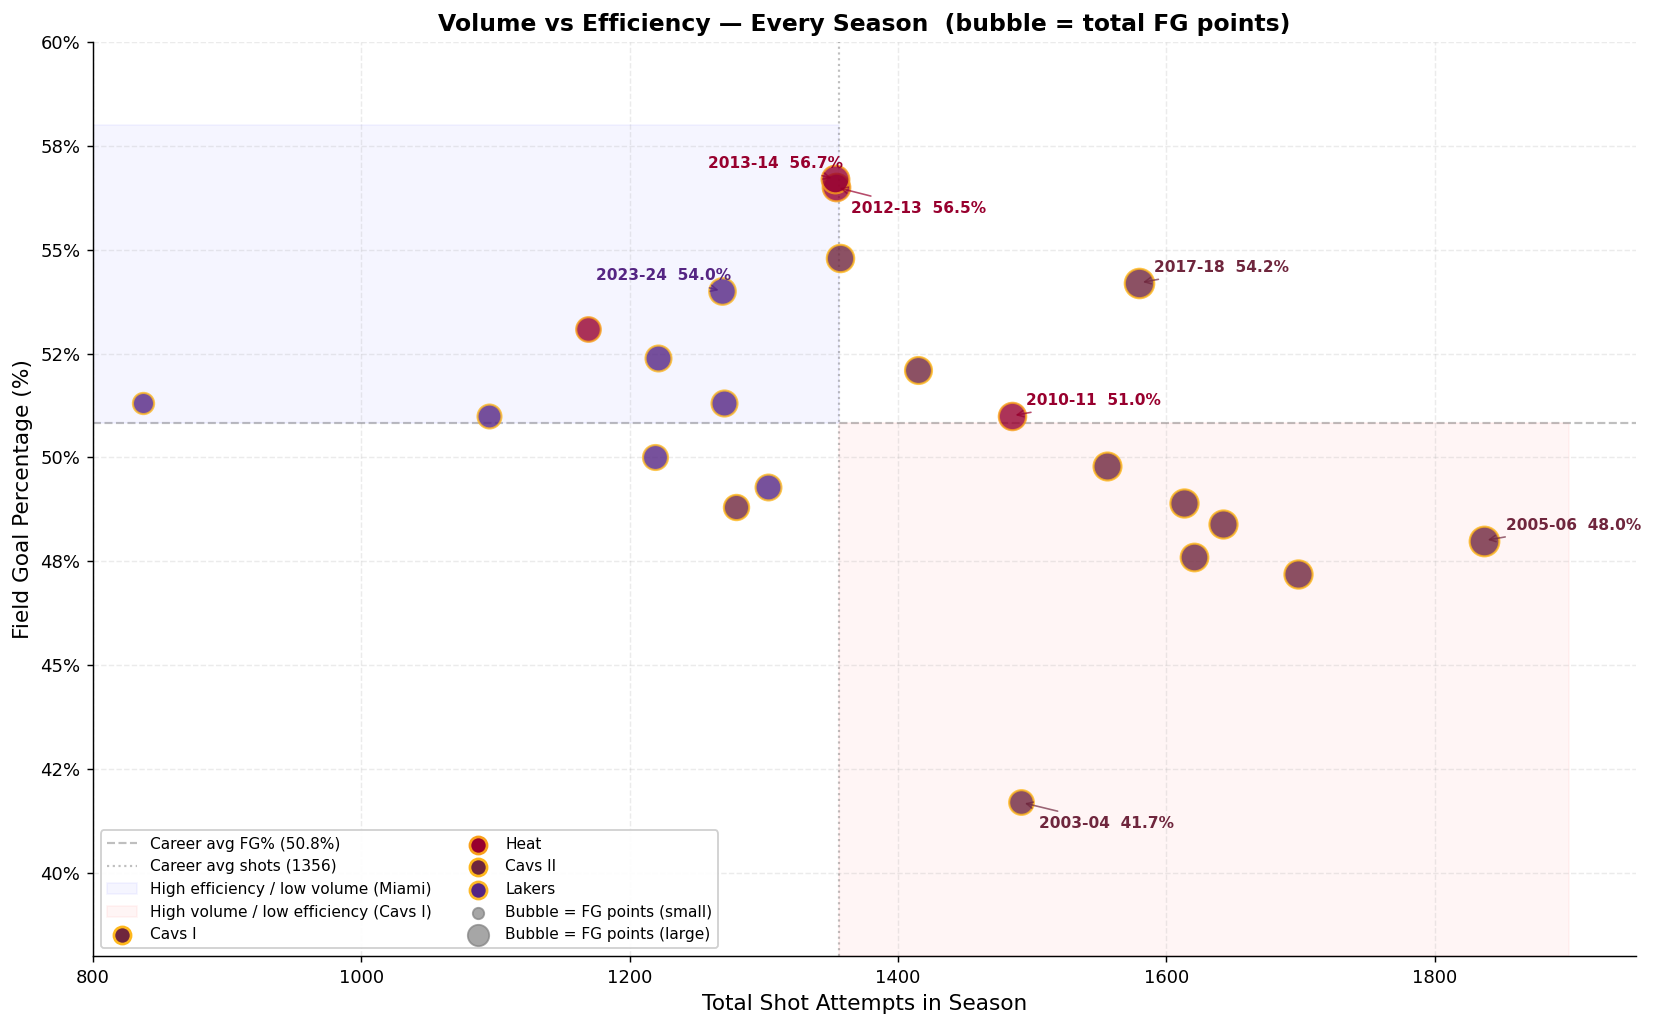

In [ ]:
# Volume vs FG% scatter  -  all seasons, bubble = total FG points
fig, ax = plt.subplots(figsize=(13, 8))

for _, row in df.iterrows():
    fc = TEAM_COLORS.get(row['tenure'], (PURPLE, GOLD))[0]
    ec = TEAM_COLORS.get(row['tenure'], (PURPLE, GOLD))[1]
    ax.scatter(row['total_shots'], row['fg_pct'],
               color=fc, edgecolors=ec, linewidths=1.2,
               s=row['total_points'] / 7, alpha=0.80, zorder=3)

# annotate key seasons
annotate = {
    '2005-06': (12,6),
    '2003-04': (10, -14),
    '2013-14': (-70, 6),
    '2012-13': (8,  -14),
    '2017-18': (8,   6),
    '2023-24': (-70, 6),
    '2010-11': (8,   6),
}
for _, row in df.iterrows():
    if row['season'] in annotate:
        xoff, yoff = annotate[row['season']]
        fc = TEAM_COLORS.get(row['tenure'], (PURPLE, GOLD))[0]
        ax.annotate(
            f"{row['season']}  {row['fg_pct']:.1f}%",
            xy=(row['total_shots'], row['fg_pct']),
            xytext=(xoff, yoff), textcoords='offset points',
            fontsize=8.5, fontweight='bold', color=fc,
            arrowprops=dict(arrowstyle='->', color=fc, lw=0.9, alpha=0.7),
        )

avg_fg   = df['fg_pct'].mean()
avg_shots = df['total_shots'].mean()
ax.axhline(avg_fg,    color='grey', lw=1.2, ls='--', alpha=0.5,
           label=f'Career avg FG% ({avg_fg:.1f}%)')
ax.axvline(avg_shots, color='grey', lw=1.2, ls=':', alpha=0.5,
           label=f'Career avg shots ({avg_shots:.0f})')

# shade quadrants
ax.fill_betweenx([avg_fg, 58], 800, avg_shots, alpha=0.04, color='blue',
                 label='High efficiency / low volume (Miami)')
ax.fill_betweenx([38, avg_fg], avg_shots, 1900, alpha=0.04, color='red',
                 label='High volume / low efficiency (Cavs I)')

for t, (fc, ec) in TEAM_COLORS.items():
    ax.scatter([], [], color=fc, edgecolors=ec, lw=1.5, s=90, label=t)
ax.scatter([], [], color='grey', s=40,  alpha=0.7, label='Bubble = FG points (small)')
ax.scatter([], [], color='grey', s=140, alpha=0.7, label='Bubble = FG points (large)')

ax.set_xlabel('Total Shot Attempts in Season', fontsize=12)
ax.set_ylabel('Field Goal Percentage (%)', fontsize=12)
ax.set_title('Volume vs Efficiency  -  Every Season  (bubble = total FG points)',
             fontsize=13, fontweight='bold')
ax.set_xlim(800, 1950)
ax.set_ylim(38, 60)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.legend(fontsize=8.5, loc='lower left', framealpha=0.92, ncol=2)
plt.tight_layout()
plt.show()

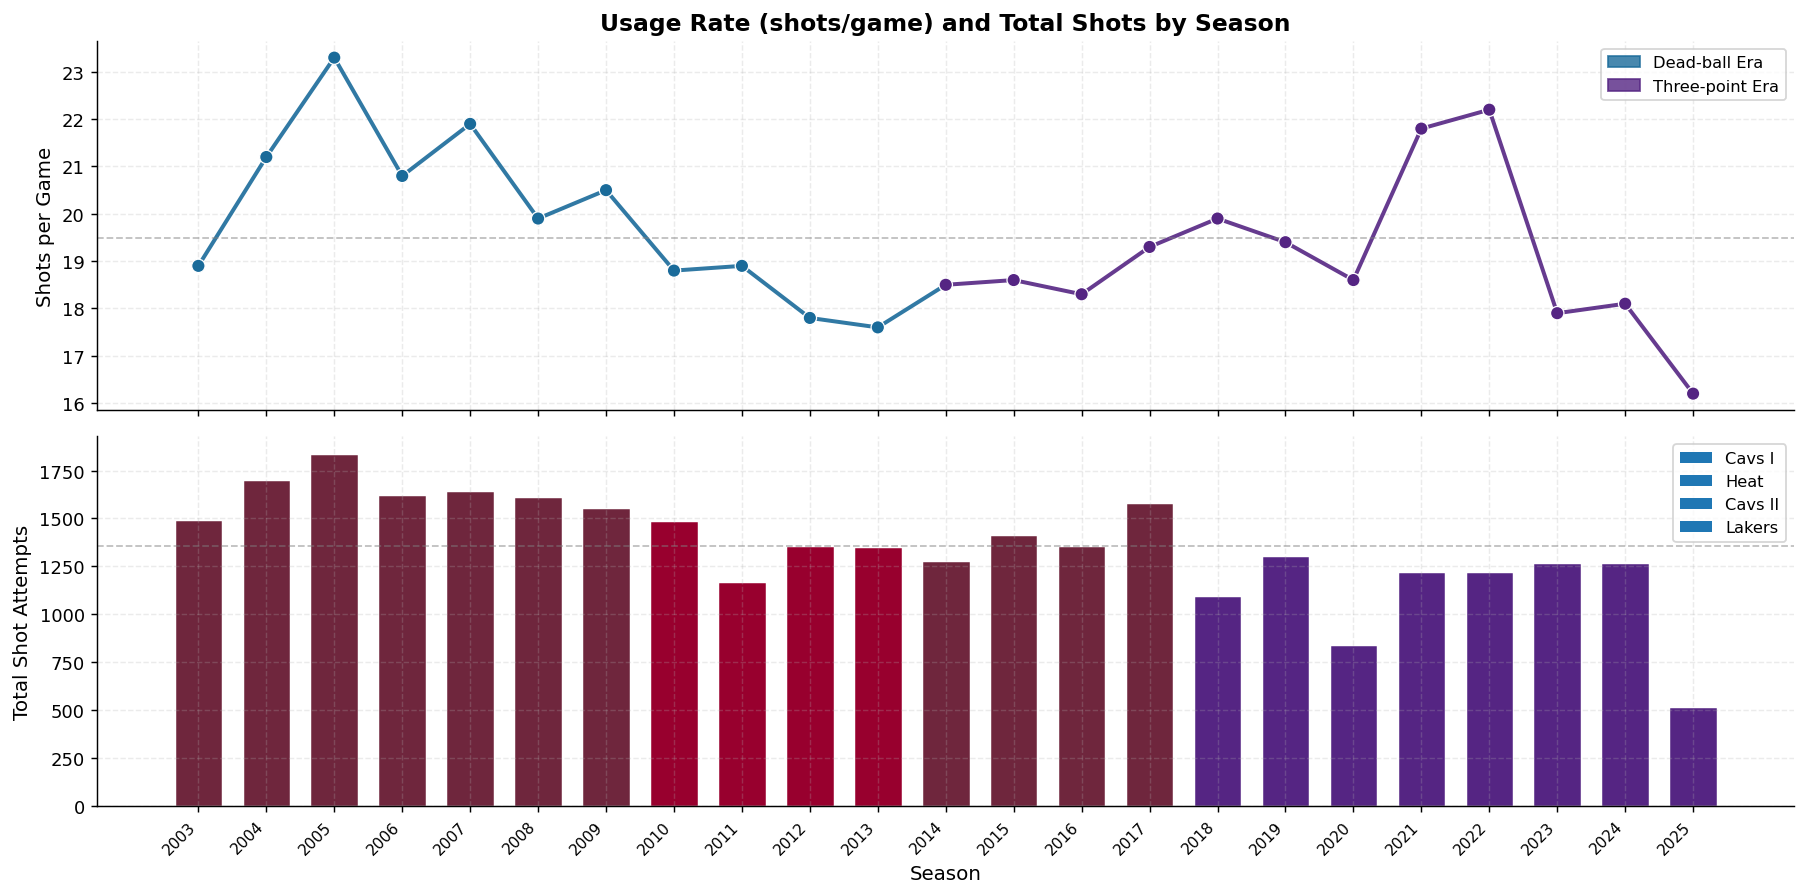

In [6]:
# Volume trend across career  -  how usage evolved
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

x    = np.arange(len(df))
clrs = [ERA_DEAD if e == 'Dead-ball Era' else ERA_THREE for e in df['era']]

# top: shots per game
for i in range(len(x) - 1):
    axes[0].plot(x[i:i+2], df['shots_per_game'].iloc[i:i+2],
                 color=clrs[i], lw=2.2, alpha=0.9)
axes[0].scatter(x, df['shots_per_game'], c=clrs, s=55, zorder=5,
                edgecolors='white', lw=0.7)
axes[0].axhline(df['shots_per_game'].mean(), color='grey', lw=1, ls='--', alpha=0.5)
axes[0].set_ylabel('Shots per Game', fontsize=11)
axes[0].set_title('Usage Rate (shots/game) and Total Shots by Season',
                  fontsize=13, fontweight='bold')

# bottom: total shots (bar)
bar_colors = [TEAM_COLORS.get(t, (PURPLE, GOLD))[0] for t in df['tenure']]
axes[1].bar(x, df['total_shots'], color=bar_colors, edgecolor='white',
            lw=0.8, width=0.7)
axes[1].axhline(df['total_shots'].mean(), color='grey', lw=1, ls='--', alpha=0.5)
axes[1].set_ylabel('Total Shot Attempts', fontsize=11)

axes[1].set_xticks(x)
axes[1].set_xticklabels(df['season'].str[:4], rotation=45, ha='right', fontsize=8.5)
axes[1].set_xlabel('Season', fontsize=11)

# tenure legend
for t, (fc, ec) in TEAM_COLORS.items():
    axes[1].bar([], [], color=fc, edgecolor=ec, lw=1.5, label=t)
axes[1].legend(fontsize=9, loc='upper right')

dead_p  = mpatches.Patch(color=ERA_DEAD,  alpha=0.8, label='Dead-ball Era')
three_p = mpatches.Patch(color=ERA_THREE, alpha=0.8, label='Three-point Era')
axes[0].legend(handles=[dead_p, three_p], fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

## 4. Best Season by Scoring (Total Field-Goal Points)

Scoring = volume × efficiency. The top scoring season is whichever year he took enough shots at high enough conversion to maximize total output.

Finding: 2005-06 leads with 1,891 FG points on 1,837 shots at 48.0%. Volume carries it over the line. But the number directly below it matters more: 2017-18 Cavs II produced 1,863 points on 1,580 shots at 54.2%. Nearly identical output, 257 fewer shots, six percentage points better efficiency.

Miami seasons are absent from the top five despite having his highest FG% because Spoelstra deliberately kept LeBron's usage lower - fewer shots, better spots. Peak efficiency doesn't produce the most raw points if the shot count is reduced enough.


In [7]:
top_pts = df.nsmallest(10, 'rank_by_points').copy()
top_pts.index = range(1, 11)

display(top_pts[[
    'season', 'tenure', 'total_points', 'points_per_game',
    'total_shots', 'fg_pct', 'points_per_shot'
]].style
    .background_gradient(subset=['total_points'],    cmap='Purples')
    .background_gradient(subset=['points_per_shot'], cmap='RdYlGn', vmin=0.87, vmax=1.22)
    .background_gradient(subset=['fg_pct'],          cmap='RdYlGn', vmin=41,   vmax=57)
    .bar(subset=['points_per_game'], color='#c9b3d9', vmin=16, vmax=25)
    .format({
        'total_points': '{:,}',
        'points_per_game': '{:.1f}',
        'total_shots': '{:,}',
        'fg_pct': '{:.1f}%',
        'points_per_shot': '{:.3f}',
    })
    .set_caption('Top 10 Seasons by Total FG Points'))

,season,tenure,total_points,points_per_game,total_shots,fg_pct,points_per_shot
1,2005-06,Cavs I,"1,891.0",23.9,"1,837",48.0%,1.029
2,2017-18,Cavs II,"1,863.0",22.7,"1,580",54.2%,1.179
3,2004-05,Cavs I,"1,712.0",21.4,"1,698",47.2%,1.008
4,2008-09,Cavs I,"1,710.0",21.1,"1,613",48.9%,1.060
5,2007-08,Cavs I,"1,701.0",22.7,"1,642",48.4%,1.036
6,2009-10,Cavs I,"1,679.0",22.1,"1,556",49.8%,1.079
7,2013-14,Heat,"1,650.0",21.4,"1,353",56.7%,1.220
8,2006-07,Cavs I,"1,643.0",21.1,"1,621",47.6%,1.014
9,2012-13,Heat,"1,633.0",21.5,"1,354",56.5%,1.206
10,2016-17,Cavs II,"1,610.0",21.8,"1,357",54.8%,1.186


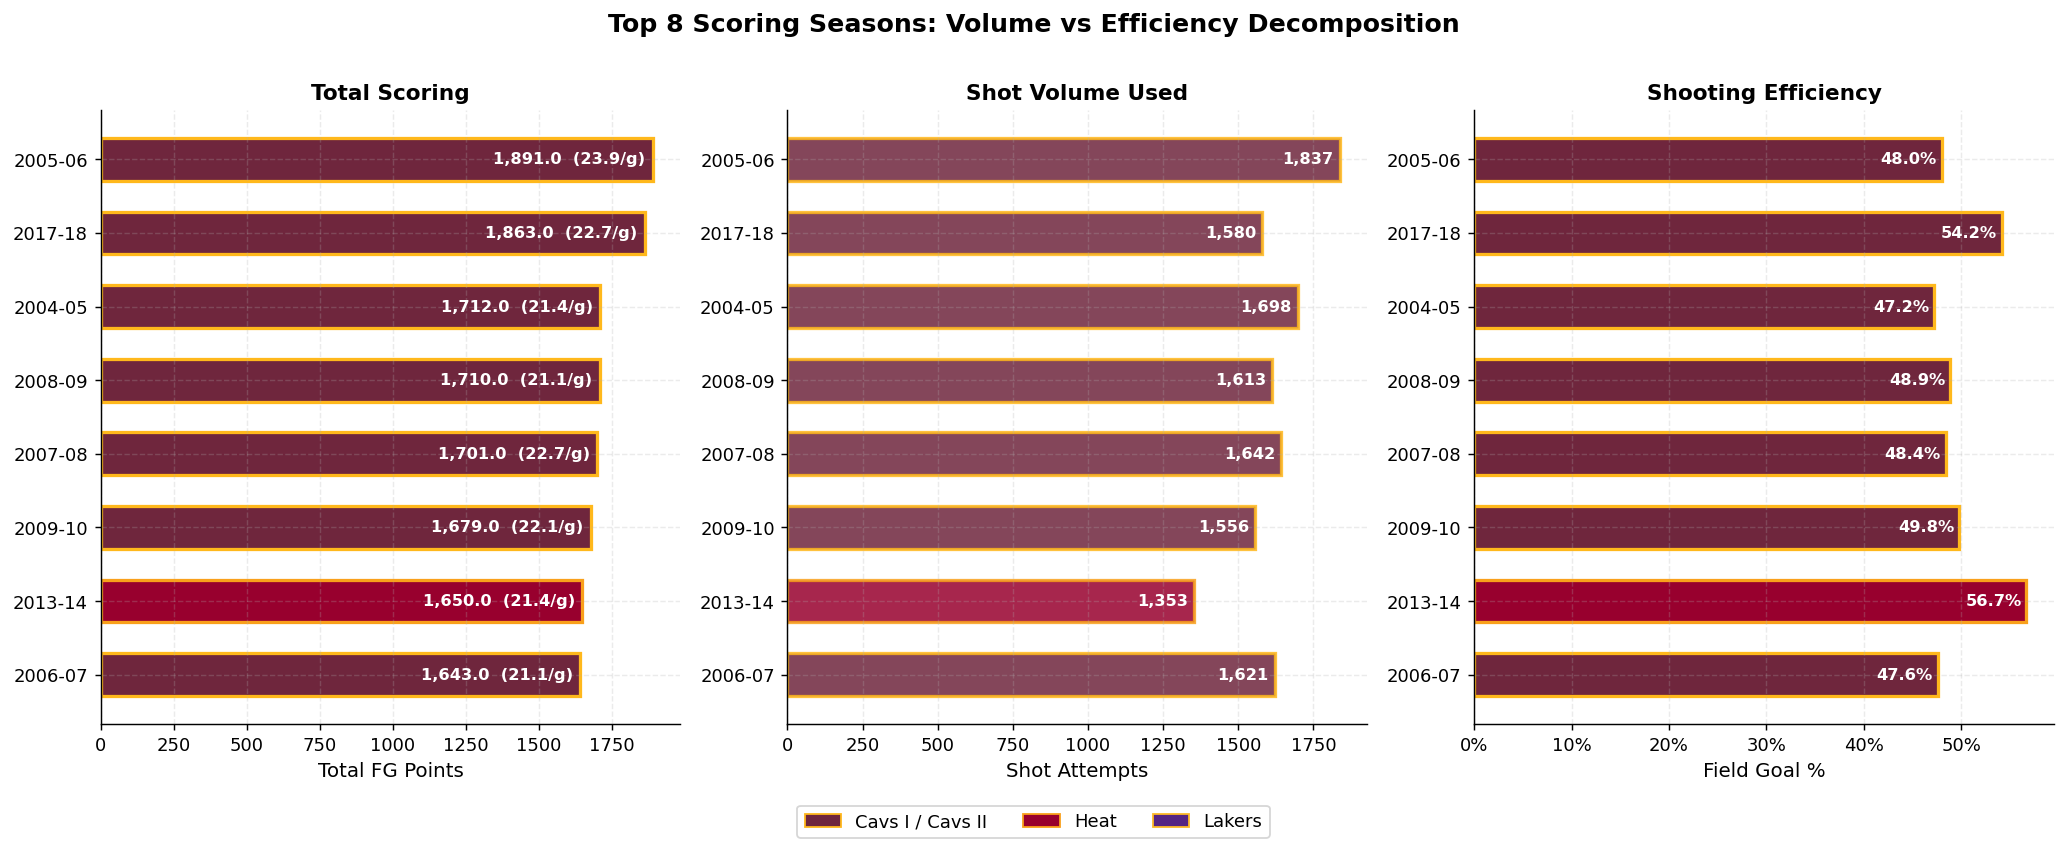

In [8]:
# Two routes to scoring: volume path vs efficiency path
top8 = df.nsmallest(8, 'rank_by_points').sort_values('total_points', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# left: total points bar
y  = np.arange(len(top8))
fc = [TEAM_COLORS.get(t, (PURPLE, GOLD))[0] for t in top8['tenure']]
ec = [TEAM_COLORS.get(t, (PURPLE, GOLD))[1] for t in top8['tenure']]

axes[0].barh(y, top8['total_points'], color=fc, edgecolor=ec, lw=1.8, height=0.58)
for i, (pts, ppg) in enumerate(zip(top8['total_points'], top8['points_per_game'])):
    axes[0].text(pts - 25, i, f'{pts:,}  ({ppg:.1f}/g)',
                 va='center', ha='right', fontsize=9, fontweight='bold', color='white')
axes[0].set_yticks(y)
axes[0].set_yticklabels(top8['season'], fontsize=10)
axes[0].set_xlabel('Total FG Points', fontsize=11)
axes[0].set_title('Total Scoring', fontsize=12, fontweight='bold')

# middle: shots taken
axes[1].barh(y, top8['total_shots'], color=fc, edgecolor=ec, lw=1.8, height=0.58, alpha=0.85)
for i, s in enumerate(top8['total_shots']):
    axes[1].text(s - 20, i, f'{s:,}',
                 va='center', ha='right', fontsize=9, fontweight='bold', color='white')
axes[1].set_yticks(y)
axes[1].set_yticklabels(top8['season'], fontsize=10)
axes[1].set_xlabel('Shot Attempts', fontsize=11)
axes[1].set_title('Shot Volume Used', fontsize=12, fontweight='bold')

# right: FG% (efficiency route)
axes[2].barh(y, top8['fg_pct'], color=fc, edgecolor=ec, lw=1.8, height=0.58)
for i, fg in enumerate(top8['fg_pct']):
    axes[2].text(fg - 0.5, i, f'{fg:.1f}%',
                 va='center', ha='right', fontsize=9, fontweight='bold', color='white')
axes[2].set_yticks(y)
axes[2].set_yticklabels(top8['season'], fontsize=10)
axes[2].set_xlabel('Field Goal %', fontsize=11)
axes[2].set_title('Shooting Efficiency', fontsize=12, fontweight='bold')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

legend_handles = [
    mpatches.Patch(facecolor=CAVS_WINE, edgecolor=CAVS_GOLD, label='Cavs I / Cavs II'),
    mpatches.Patch(facecolor=HEAT_RED,  edgecolor='#F9A01B', label='Heat'),
    mpatches.Patch(facecolor=PURPLE,    edgecolor=GOLD,       label='Lakers'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.06))
plt.suptitle('Top 8 Scoring Seasons: Volume vs Efficiency Decomposition',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

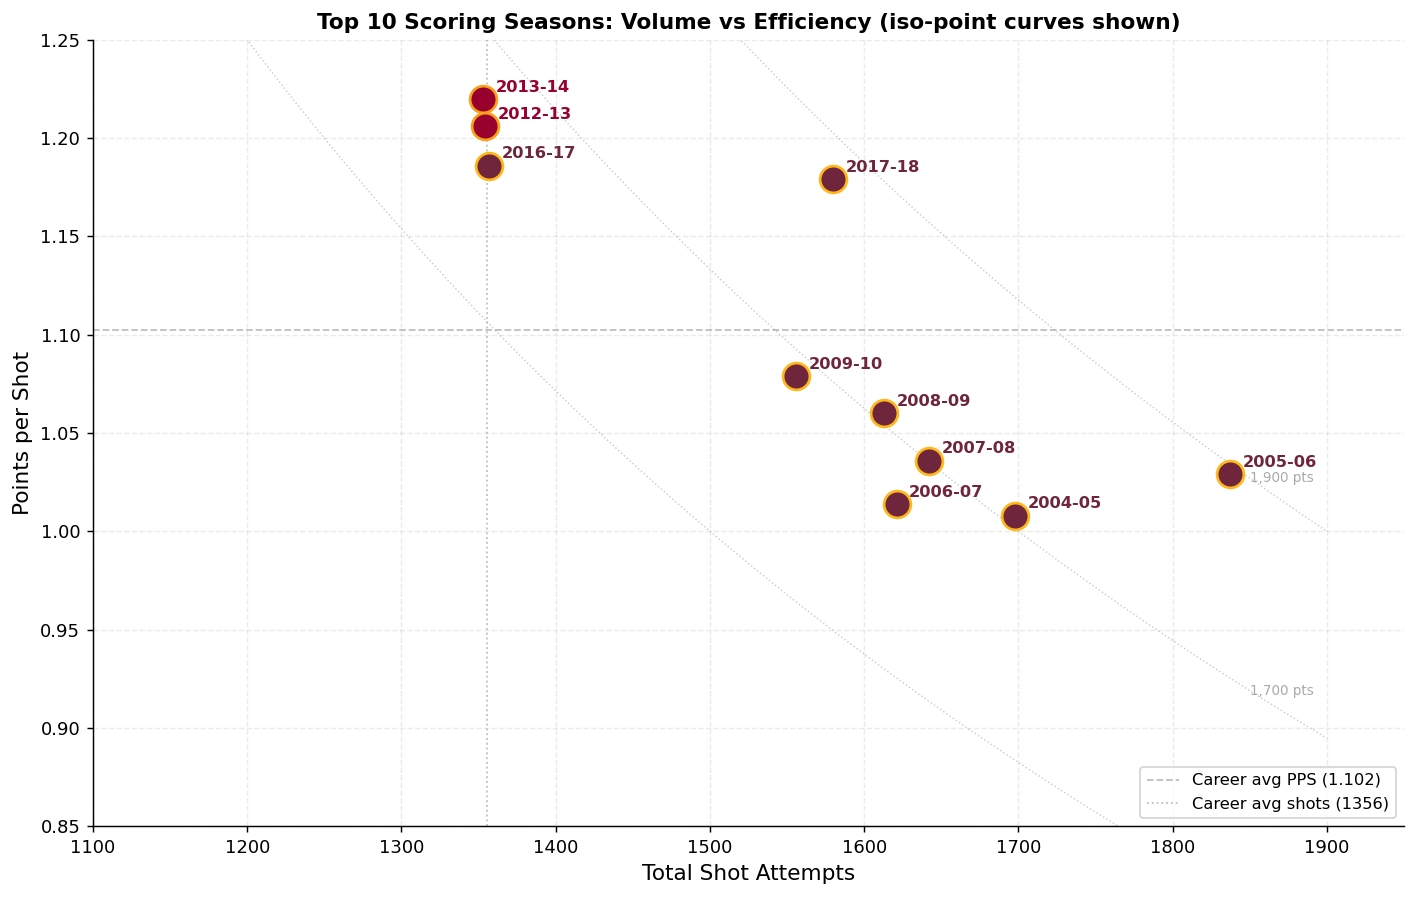

In [9]:
# Scatter: shots × points_per_shot for top scoring seasons
# Shows which seasons scored through volume vs through efficiency
fig, ax = plt.subplots(figsize=(11, 7))

top10_pts = df.nsmallest(10, 'rank_by_points')
for _, row in top10_pts.iterrows():
    fc = TEAM_COLORS.get(row['tenure'], (PURPLE, GOLD))[0]
    ec = TEAM_COLORS.get(row['tenure'], (PURPLE, GOLD))[1]
    ax.scatter(row['total_shots'], row['points_per_shot'],
               color=fc, edgecolors=ec, lw=1.5, s=220, zorder=3)
    ax.annotate(f"{row['season']}",
                xy=(row['total_shots'], row['points_per_shot']),
                xytext=(7, 4), textcoords='offset points',
                fontsize=9, fontweight='bold', color=fc)

# reference lines at career averages
ax.axhline(df['points_per_shot'].mean(), color='grey', lw=1, ls='--', alpha=0.5,
           label=f"Career avg PPS ({df['points_per_shot'].mean():.3f})")
ax.axvline(df['total_shots'].mean(), color='grey', lw=1, ls=':', alpha=0.5,
           label=f"Career avg shots ({df['total_shots'].mean():.0f})")

# diagonal iso-scoring lines (pts = shots × pps)
for target in [1500, 1700, 1900]:
    xs = np.linspace(900, 1900, 100)
    ys = target / xs
    ax.plot(xs, ys, color='#cccccc', lw=0.8, ls=':', zorder=0)
    ax.annotate(f'{target:,} pts', xy=(1850, target/1850),
                fontsize=7.5, color='#aaaaaa', va='center')

ax.set_xlabel('Total Shot Attempts', fontsize=12)
ax.set_ylabel('Points per Shot', fontsize=12)
ax.set_title('Top 10 Scoring Seasons: Volume vs Efficiency (iso-point curves shown)',
             fontsize=12, fontweight='bold')
ax.set_xlim(1100, 1950)
ax.set_ylim(0.85, 1.25)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

## 5. Best Season by Effectiveness

Effectiveness measures conversion quality - FG% and points per shot. These metrics are independent of volume; a player who takes 800 shots can lead here.

Finding: The top two are both Miami - 2013-14 (56.7% FG, 1.220 pts/shot) and 2012-13 (56.5%, 1.206). Two consecutive seasons. Both have a low three-point rate (18-23%), very high 2-point conversion (60-62%), and a short average shot distance (~11 ft). Those conditions aligned because Spoelstra ran the offense specifically to get LeBron high-quality 2-point attempts and nothing else.

Then two Cavs II seasons (2016-17 and 2017-18), both above 54%.

The outlier: 2023-24 at #5 in FG% and #3 in points-per-shot - at age 39. The shot profile is completely different from Miami (29% threes vs 19%), yet the output numbers almost match. That's the clearest single-row summary of what his career adaptation means.


In [10]:
top_eff = df.nsmallest(10, 'rank_by_fg_pct').copy()
top_eff.index = range(1, 11)

display(top_eff[[
    'season', 'tenure', 'fg_pct', 'fg2_pct', 'fg3_pct', 'three_pt_rate',
    'points_per_shot', 'avg_shot_distance', 'clutch_fg_pct'
]].style
    .background_gradient(subset=['fg_pct'],          cmap='RdYlGn', vmin=47,   vmax=57)
    .background_gradient(subset=['fg2_pct'],         cmap='RdYlGn', vmin=50,   vmax=64)
    .background_gradient(subset=['fg3_pct'],         cmap='RdYlGn', vmin=28,   vmax=43)
    .background_gradient(subset=['points_per_shot'], cmap='RdYlGn', vmin=0.87, vmax=1.22)
    .background_gradient(subset=['three_pt_rate'],   cmap='Blues',  vmin=12,   vmax=38)
    .bar(subset=['avg_shot_distance'], color='#f4c97a', vmin=9, vmax=15)
    .format({
        'fg_pct': '{:.1f}%',
        'fg2_pct': '{:.1f}%',
        'fg3_pct': '{:.1f}%',
        'three_pt_rate': '{:.1f}%',
        'points_per_shot': '{:.3f}',
        'avg_shot_distance': '{:.1f} ft',
        'clutch_fg_pct': '{:.1f}%',
    })
    .set_caption('Top 10 Seasons by FG%'))

,season,tenure,fg_pct,fg2_pct,fg3_pct,three_pt_rate,points_per_shot,avg_shot_distance,clutch_fg_pct
1,2013-14,Heat,56.7%,62.2%,37.9%,22.6%,1.220,10.9 ft,53.6%
2,2012-13,Heat,56.5%,60.2%,40.6%,18.8%,1.206,10.8 ft,49.1%
3,2016-17,Cavs II,54.8%,60.9%,36.4%,25.1%,1.186,10.4 ft,51.4%
4,2017-18,Cavs II,54.2%,60.3%,36.7%,25.7%,1.179,11.0 ft,51.8%
5,2023-24,Lakers,54.0%,59.2%,41.0%,28.6%,1.197,11.2 ft,52.6%
6,2011-12,Heat,53.1%,55.6%,36.2%,12.7%,1.109,11.0 ft,43.3%
7,2021-22,Lakers,52.4%,62.0%,35.9%,36.7%,1.180,13.3 ft,44.4%
8,2015-16,Cavs II,52.1%,57.3%,31.0%,19.9%,1.103,9.6 ft,50.3%
9,2020-21,Lakers,51.3%,58.9%,36.5%,34.1%,1.149,13.2 ft,44.3%
10,2024-25,Lakers,51.3%,57.4%,37.6%,31.2%,1.143,12.9 ft,49.6%


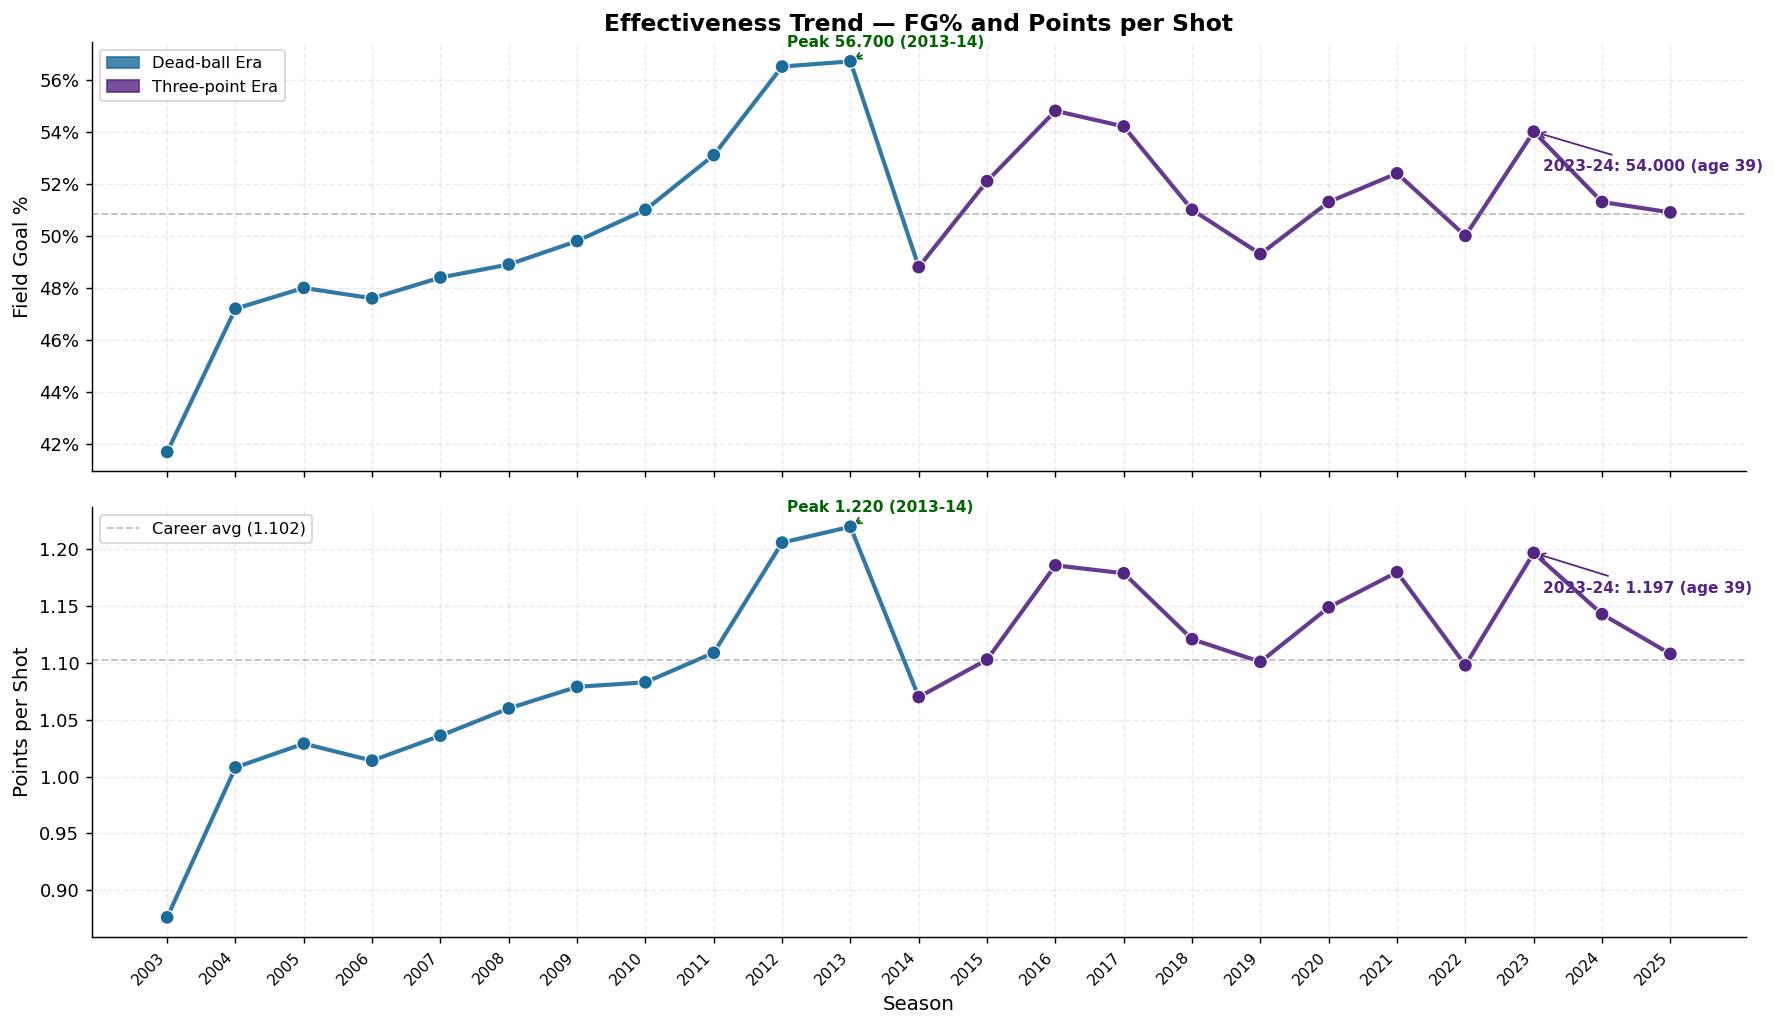

In [11]:
# FG% and PPS dual-axis trend  -  full career
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

x    = np.arange(len(df))
clrs = [ERA_DEAD if e == 'Dead-ball Era' else ERA_THREE for e in df['era']]

# FG% line
for i in range(len(x) - 1):
    axes[0].plot(x[i:i+2], df['fg_pct'].iloc[i:i+2], color=clrs[i], lw=2.3, alpha=0.9)
axes[0].scatter(x, df['fg_pct'], c=clrs, s=60, zorder=5, edgecolors='white', lw=0.7)
axes[0].axhline(df['fg_pct'].mean(), color='grey', lw=1, ls='--', alpha=0.5,
                label=f"Career avg ({df['fg_pct'].mean():.1f}%)")
axes[0].set_ylabel('Field Goal %', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
axes[0].set_title('Effectiveness Trend  -  FG% and Points per Shot',
                  fontsize=13, fontweight='bold')

# PPS line
for i in range(len(x) - 1):
    axes[1].plot(x[i:i+2], df['points_per_shot'].iloc[i:i+2], color=clrs[i], lw=2.3, alpha=0.9)
axes[1].scatter(x, df['points_per_shot'], c=clrs, s=60, zorder=5, edgecolors='white', lw=0.7)
axes[1].axhline(df['points_per_shot'].mean(), color='grey', lw=1, ls='--', alpha=0.5,
                label=f"Career avg ({df['points_per_shot'].mean():.3f})")
axes[1].set_ylabel('Points per Shot', fontsize=11)

# annotate career high and 2023-24
for ax_i, col in [(axes[0], 'fg_pct'), (axes[1], 'points_per_shot')]:
    peak_i  = df[col].idxmax()
    lak24_i = df[df['season'] == '2023-24'].index[0]
    ax_i.annotate(
        f"Peak {df[col].iloc[peak_i]:.3f} ({df['season'].iloc[peak_i]})",
        xy=(peak_i, df[col].iloc[peak_i]),
        xytext=(-35, 8), textcoords='offset points', fontsize=8.5,
        color='darkgreen', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1))
    ax_i.annotate(
        f"2023-24: {df[col].iloc[lak24_i]:.3f} (age 39)",
        xy=(lak24_i, df[col].iloc[lak24_i]),
        xytext=(5, -22), textcoords='offset points', fontsize=8.5,
        color=PURPLE, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=PURPLE, lw=1))
    ax_i.legend(fontsize=9, loc='upper left')

axes[1].set_xticks(x)
axes[1].set_xticklabels(df['season'].str[:4], rotation=45, ha='right', fontsize=8.5)
axes[1].set_xlabel('Season', fontsize=11)

dead_p  = mpatches.Patch(color=ERA_DEAD,  alpha=0.8, label='Dead-ball Era')
three_p = mpatches.Patch(color=ERA_THREE, alpha=0.8, label='Three-point Era')
axes[0].legend(handles=[dead_p, three_p], fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

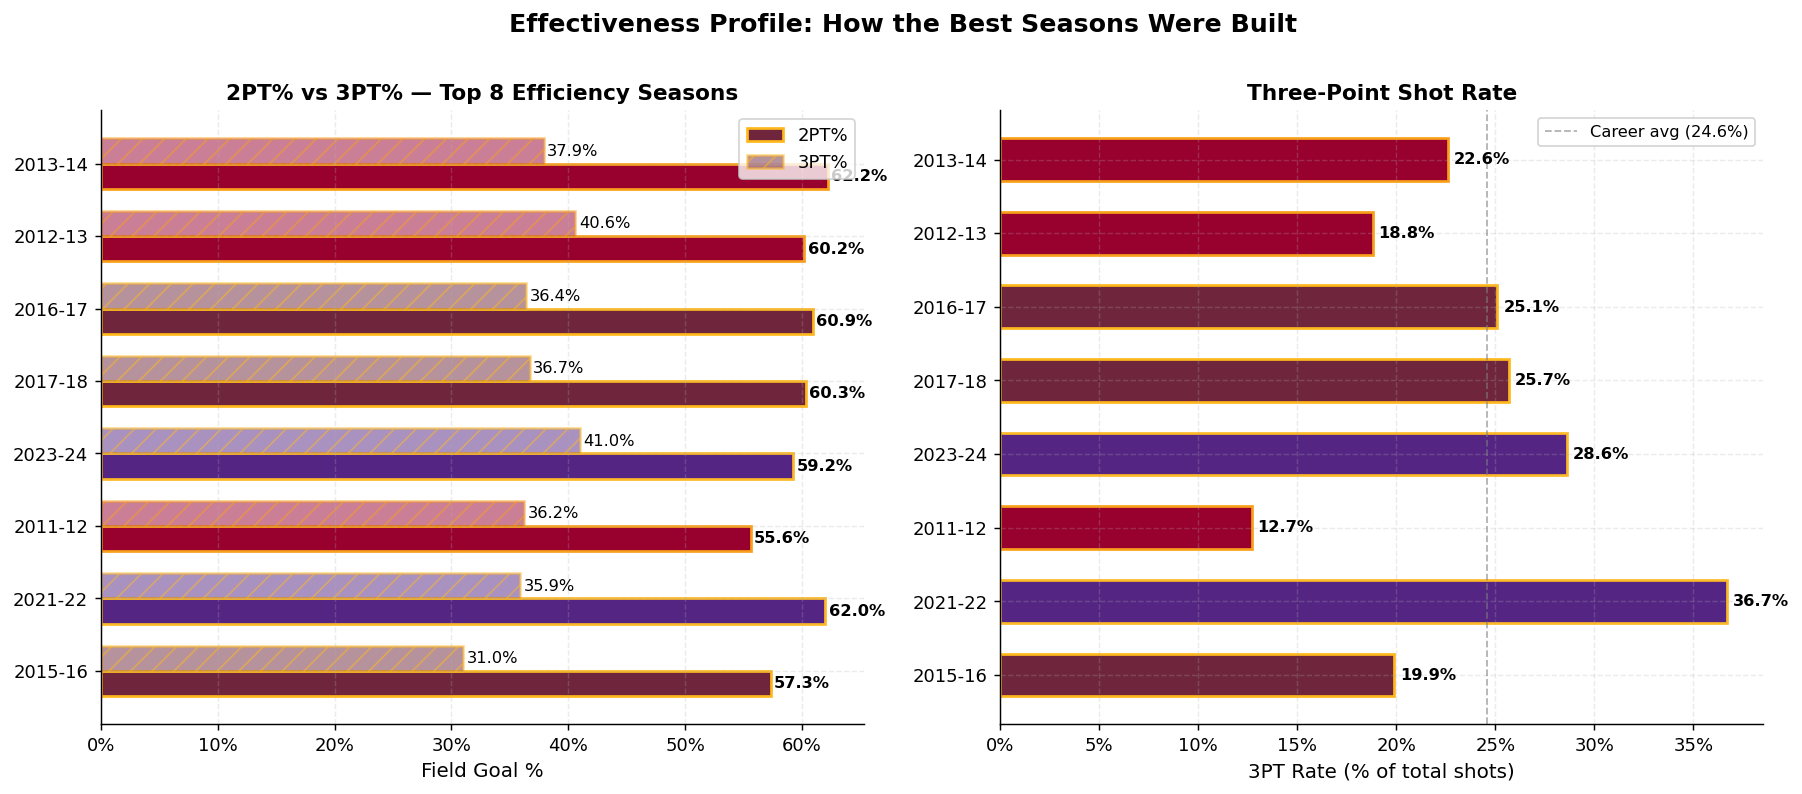

In [12]:
# Effectiveness by shot profile: 2PT% vs 3PT% grouped bar for top 8 efficiency seasons
top8_eff = df.nsmallest(8, 'rank_by_fg_pct').sort_values('fg_pct')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

y  = np.arange(len(top8_eff))
fc = [TEAM_COLORS.get(t, (PURPLE, GOLD))[0] for t in top8_eff['tenure']]
ec = [TEAM_COLORS.get(t, (PURPLE, GOLD))[1] for t in top8_eff['tenure']]

# 2PT% vs 3PT% grouped
w = 0.35
axes[0].barh(y - w/2, top8_eff['fg2_pct'], w, color=fc, edgecolor=ec, lw=1.5, label='2PT%')
axes[0].barh(y + w/2, top8_eff['fg3_pct'], w, color=fc, edgecolor=ec, lw=1.5, alpha=0.5,
             hatch='//', label='3PT%')
for i, (f2, f3) in enumerate(zip(top8_eff['fg2_pct'], top8_eff['fg3_pct'])):
    axes[0].text(f2 + 0.3, i - w/2, f'{f2:.1f}%', va='center', fontsize=9, fontweight='bold')
    axes[0].text(f3 + 0.3, i + w/2, f'{f3:.1f}%', va='center', fontsize=9)
axes[0].set_yticks(y)
axes[0].set_yticklabels(top8_eff['season'], fontsize=10)
axes[0].set_xlabel('Field Goal %', fontsize=11)
axes[0].set_title('2PT% vs 3PT%  -  Top 8 Efficiency Seasons', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

# 3PT rate (how many threes as share of total shots)
axes[1].barh(y, top8_eff['three_pt_rate'], color=fc, edgecolor=ec, lw=1.5, height=0.58)
for i, t3 in enumerate(top8_eff['three_pt_rate']):
    axes[1].text(t3 + 0.3, i, f'{t3:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_yticks(y)
axes[1].set_yticklabels(top8_eff['season'], fontsize=10)
axes[1].set_xlabel('3PT Rate (% of total shots)', fontsize=11)
axes[1].set_title('Three-Point Shot Rate', fontsize=12, fontweight='bold')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
axes[1].axvline(df['three_pt_rate'].mean(), color='grey', lw=1, ls='--', alpha=0.6,
                label=f"Career avg ({df['three_pt_rate'].mean():.1f}%)")
axes[1].legend(fontsize=9)

plt.suptitle('Effectiveness Profile: How the Best Seasons Were Built',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Miami 2013-14 vs Lakers 2023-24: Same Output, Different Method

The most instructive comparison in the dataset. Two seasons with nearly identical efficiency numbers, separated by a decade and completely different shot profiles.

| Metric | 2013-14 Heat | 2023-24 Lakers |
|--------|-------------|---------------|
| FG% | 56.7% | 54.0% |
| Points/Shot | 1.220 | 1.197 |
| 2PT% | 62.2% | 59.2% |
| 3PT% | 37.9% | 41.0% |
| 3PT Rate (% of shots) | 22.6% | 28.6% |
| Avg shot distance | 10.9 ft | 11.2 ft |
| Total shots | 1,353 | 1,269 |

2013-14: lower three-point rate, fewer long-range attempts, more time in the paint. 2023-24: more threes and at higher accuracy, slightly fewer 2-point attempts. The two profiles arrive at essentially the same scoring efficiency from opposite directions. That's not luck - it's the same player adapting the method while holding the output steady.


In [13]:
compare_seasons = ['2013-14', '2023-24']
cdf = df[df['season'].isin(compare_seasons)].set_index('season')

metrics_map = {
    'fg_pct': 'FG%',
    'fg2_pct': '2PT FG%',
    'fg3_pct': '3PT FG%',
    'three_pt_rate': '3PT Rate',
    'points_per_shot': 'Pts per Shot',
    'avg_shot_distance': 'Avg Distance (ft)',
    'clutch_fg_pct': 'Clutch FG%',
    'total_shots': 'Total Shots',
    'total_points': 'Total FG Points',
    'games_played': 'Games',
}

compare_t = cdf[list(metrics_map.keys())].T.copy()
compare_t.index = list(metrics_map.values())
compare_t.columns.name = None

# custom format
def fmt_cell(v):
    if abs(v) > 100:
        return f'{v:,.0f}'
    elif abs(v) < 2:
        return f'{v:.3f}'
    else:
        return f'{v:.1f}%'

print("Miami 2013-14 (peak efficiency) vs Lakers 2023-24 (age 39)")
print("Same output  -  different method")
display(compare_t.style
    .background_gradient(cmap='RdYlGn', axis=1, vmin=0, vmax=1)
    .format(fmt_cell)
    .set_caption('Peak Season Comparison: 2013-14 Heat vs 2023-24 Lakers'))

Miami 2013-14 (peak efficiency) vs Lakers 2023-24 (age 39)
Same output  -  different method


,2013-14,2023-24
FG%,56.7%,54.0%
2PT FG%,62.2%,59.2%
3PT FG%,37.9%,41.0%
3PT Rate,22.6%,28.6%
Pts per Shot,1.220,1.197
Avg Distance (ft),10.9%,11.2%
Clutch FG%,53.6%,52.6%
Total Shots,"1,353","1,269"
Total FG Points,"1,650","1,519"
Games,77.0%,71.0%


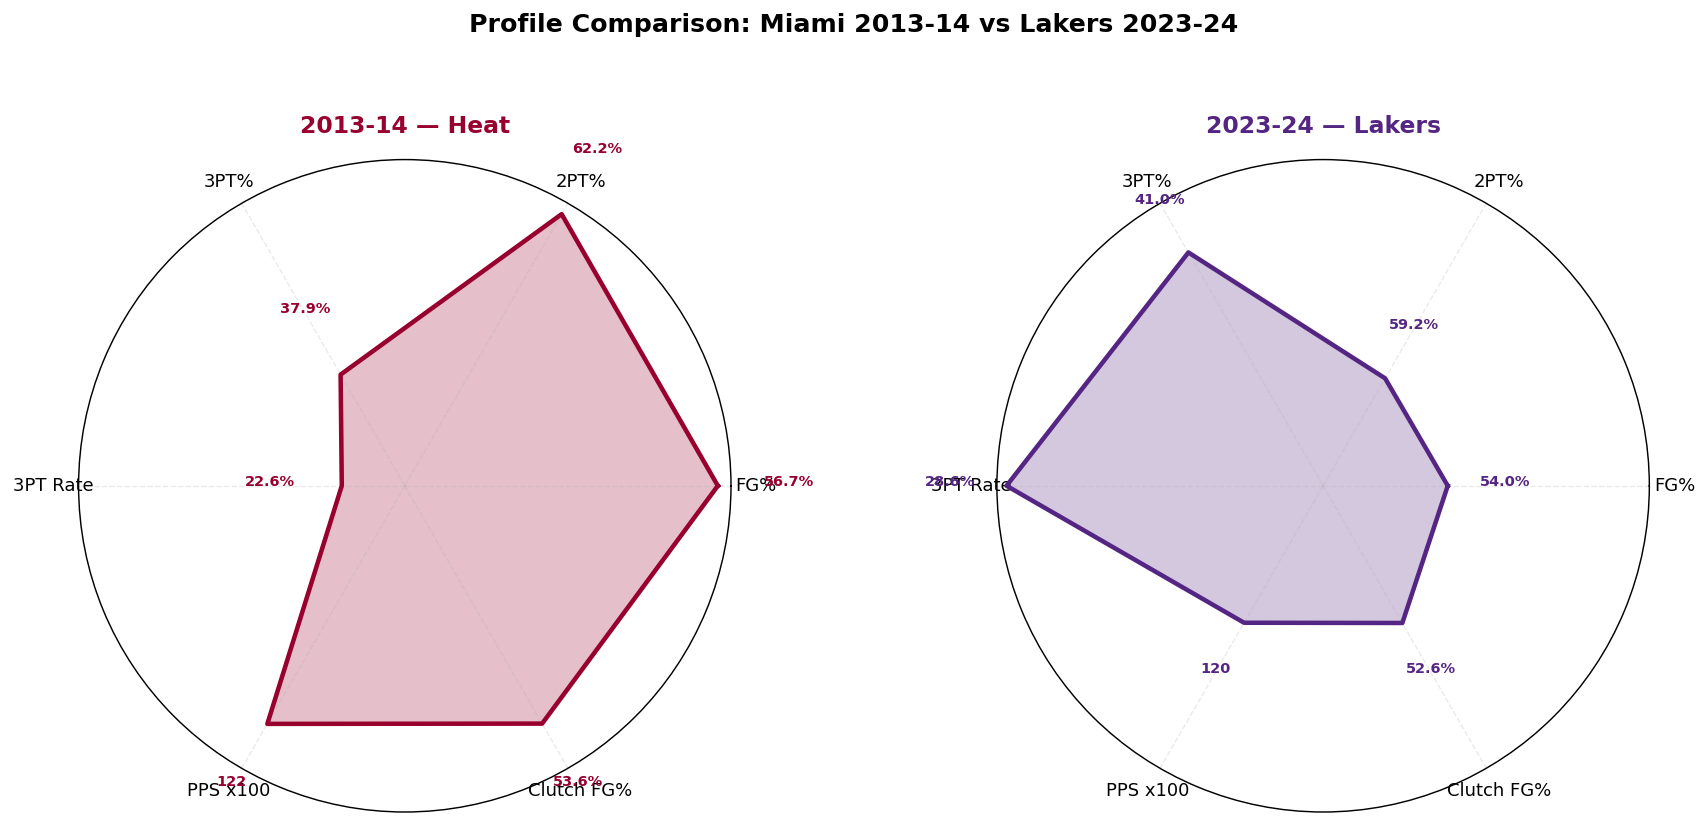

In [14]:
# Radar / spider chart comparing the two seasons
metrics_radar = ['fg_pct', 'fg2_pct', 'fg3_pct', 'three_pt_rate',
                 'points_per_shot_scaled', 'clutch_fg_pct']
labels_radar  = ['FG%', '2PT%', '3PT%', '3PT Rate', 'PPS x100', 'Clutch FG%']

s1 = cdf.loc['2013-14'].copy()
s2 = cdf.loc['2023-24'].copy()
s1['points_per_shot_scaled'] = s1['points_per_shot'] * 100
s2['points_per_shot_scaled'] = s2['points_per_shot'] * 100

vals1 = [s1[m] for m in metrics_radar]
vals2 = [s2[m] for m in metrics_radar]

# normalize each metric to 0-1 scale for the radar
all_vals = [[s1[m], s2[m]] for m in metrics_radar]
mins = [min(v) * 0.95 for v in all_vals]
maxs = [max(v) * 1.05 for v in all_vals]
norm1 = [(v - mn) / (mx - mn) if mx > mn else 0.5
         for v, mn, mx in zip(vals1, mins, maxs)]
norm2 = [(v - mn) / (mx - mn) if mx > mn else 0.5
         for v, mn, mx in zip(vals2, mins, maxs)]

N    = len(labels_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
norm1 += norm1[:1]
norm2 += norm2[:1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw=dict(polar=True))

for ax_r, nv, season, color, team in [
    (axes[0], norm1, '2013-14', HEAT_RED, 'Heat'),
    (axes[1], norm2, '2023-24', PURPLE,   'Lakers'),
]:
    ax_r.plot(angles, nv, color=color, lw=2.5)
    ax_r.fill(angles, nv, color=color, alpha=0.25)
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(labels_radar, size=10)
    ax_r.set_yticks([])
    ax_r.set_title(f'{season}  -  {team}', size=13, fontweight='bold',
                   pad=15, color=color)
    # add actual values as annotations
    for angle, nv_i, raw_v, lbl in zip(angles[:-1], nv[:-1], vals1 if nv is norm1 else vals2, labels_radar):
        x_pos = angle + 0.05
        if raw_v > 100:
            txt = f'{raw_v:,.0f}'
        elif raw_v < 2:
            txt = f'{raw_v:.3f}'
        else:
            txt = f'{raw_v:.1f}%'
        ax_r.annotate(txt, xy=(angle, nv_i),
                     xytext=(angle, min(nv_i + 0.15, 1.05)),
                     fontsize=8, ha='center', color=color, fontweight='bold')

plt.suptitle('Profile Comparison: Miami 2013-14 vs Lakers 2023-24',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## 7. Multi-Dimension Combined Ranking

To identify the "best overall" season, we sum the four rank columns:
- `rank_by_shots` - volume rank (1 = most shots)
- `rank_by_points` - scoring rank (1 = most FG points)
- `rank_by_fg_pct` - efficiency rank (1 = highest FG%)
- `rank_by_pps` - points-per-shot rank (1 = highest)

Lower combined rank = better across more dimensions simultaneously. A season that ranks #1 in everything would score 4. A season that only dominates one metric while ranking poorly in others will have a high combined score.

Key result: No single season dominates all four metrics. The volume leaders (Cavs I) rank poorly in efficiency. The efficiency leaders (Heat 2013-14) rank poorly in volume. 2017-18 Cavs II has the most balanced profile - #2 in scoring, #4 in FG%, in the top 10 in volume. It's the closest thing to an all-around best season in the data.


In [15]:
rank_df = df[[
    'season', 'tenure', 'total_shots', 'fg_pct', 'points_per_shot', 'total_points',
    'rank_by_shots', 'rank_by_points', 'rank_by_fg_pct', 'rank_by_pps'
]].copy()
rank_df['combined_rank'] = (rank_df['rank_by_shots']  +
                             rank_df['rank_by_points'] +
                             rank_df['rank_by_fg_pct'] +
                             rank_df['rank_by_pps'])
rank_df = rank_df.sort_values('combined_rank').reset_index(drop=True)
rank_df.index = range(1, len(rank_df) + 1)

display(rank_df.style
    .background_gradient(subset=['rank_by_shots'],  cmap='Blues_r',   vmin=1, vmax=23)
    .background_gradient(subset=['rank_by_points'], cmap='Purples_r', vmin=1, vmax=23)
    .background_gradient(subset=['rank_by_fg_pct'], cmap='Greens_r',  vmin=1, vmax=23)
    .background_gradient(subset=['rank_by_pps'],    cmap='Oranges_r', vmin=1, vmax=23)
    .background_gradient(subset=['fg_pct'],         cmap='RdYlGn',    vmin=41, vmax=57)
    .bar(subset=['combined_rank'], color='#e0c9e8', vmin=4, vmax=90)
    .format({
        'total_shots': '{:,}',
        'fg_pct': '{:.1f}%',
        'points_per_shot':'{:.3f}',
        'total_points': '{:,}',
        'combined_rank': '{:.0f}',
    })
    .set_caption('All 23 Seasons  -  Combined Rank (lower = better across all dimensions)'))

,season,tenure,total_shots,fg_pct,points_per_shot,total_points,rank_by_shots,rank_by_points,rank_by_fg_pct,rank_by_pps,combined_rank
1,2017-18,Cavs II,"1,580",54.2%,1.179,"1,863.0",6,2,4,6,18
2,2013-14,Heat,"1,353",56.7%,1.220,"1,650.0",13,7,1,1,22
3,2012-13,Heat,"1,354",56.5%,1.206,"1,633.0",12,9,2,2,25
4,2016-17,Cavs II,"1,357",54.8%,1.186,"1,610.0",11,10,3,4,28
5,2023-24,Lakers,"1,269",54.0%,1.197,"1,519.0",17,13,5,3,38
6,2005-06,Cavs I,"1,837",48.0%,1.029,"1,891.0",1,1,20,20,42
7,2015-16,Cavs II,"1,415",52.1%,1.103,"1,561.0",10,12,8,12,42
8,2009-10,Cavs I,"1,556",49.8%,1.079,"1,679.0",7,6,15,16,44
9,2008-09,Cavs I,"1,613",48.9%,1.060,"1,710.0",5,4,17,18,44
10,2021-22,Lakers,"1,221",52.4%,1.180,"1,441.0",18,15,7,5,45


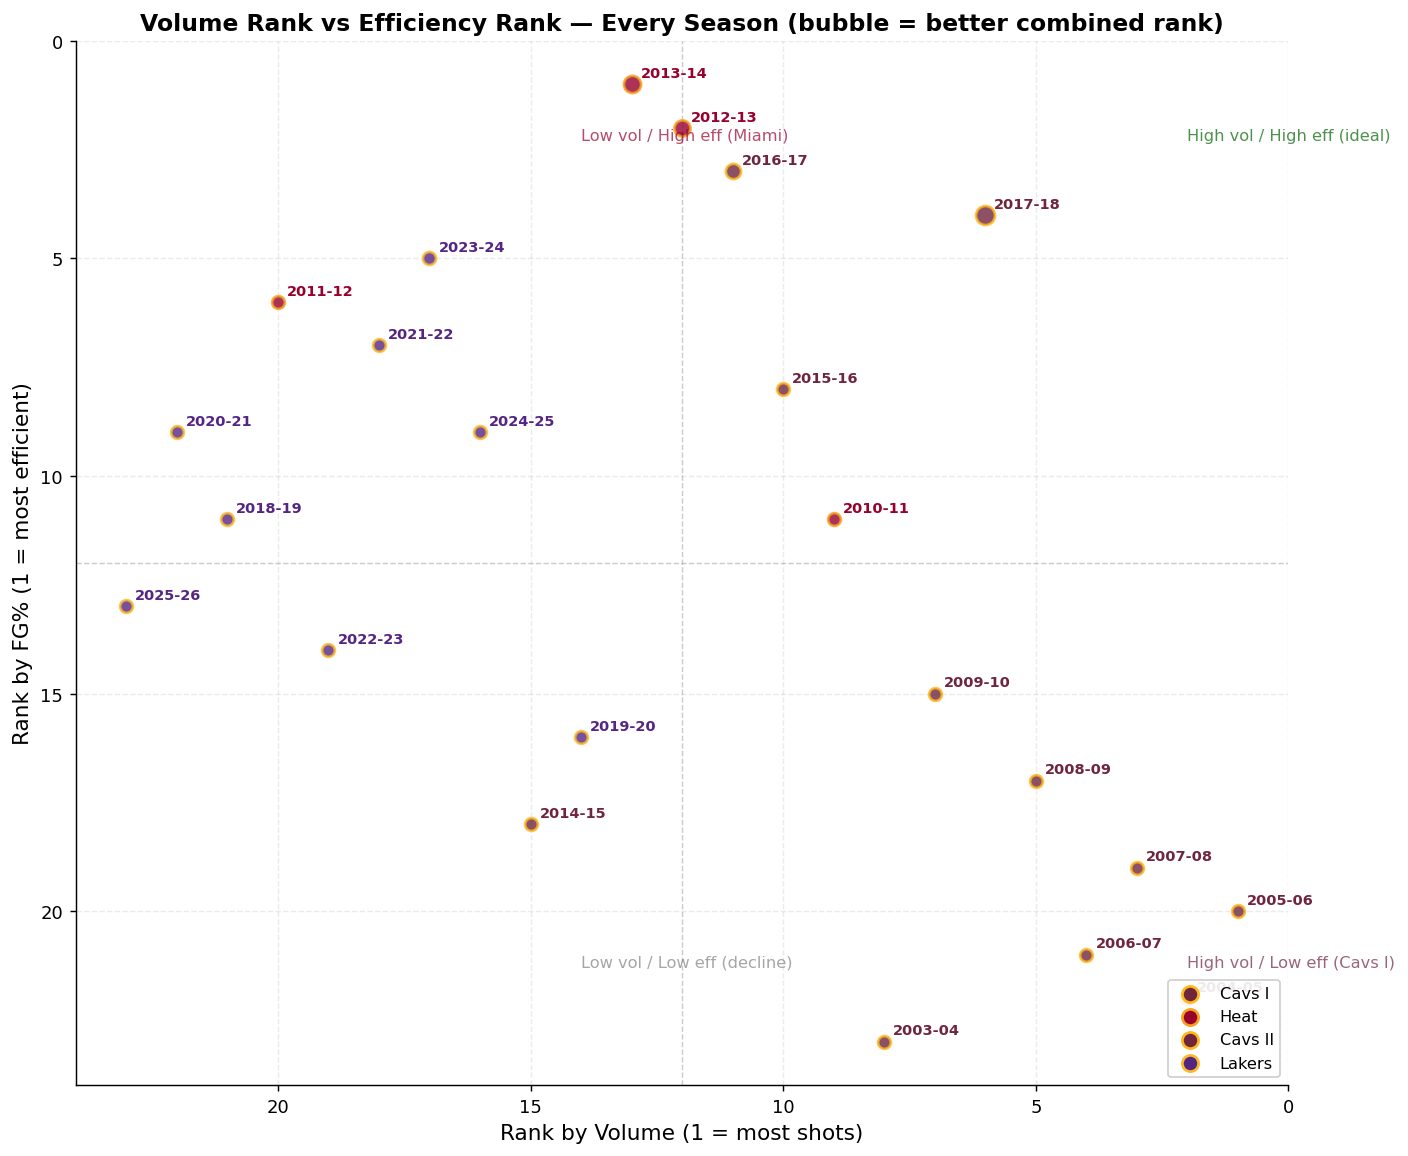

In [16]:
# Quadrant chart: volume rank vs efficiency rank  -  shows the tradeoff clearly
fig, ax = plt.subplots(figsize=(11, 9))

for _, row in rank_df.iterrows():
    fc = TEAM_COLORS.get(row['tenure'], (PURPLE, GOLD))[0]
    ec = TEAM_COLORS.get(row['tenure'], (PURPLE, GOLD))[1]
    # bubble size inversely proportional to combined rank (better = bigger)
    sz = max(50, 2000 / row['combined_rank'])
    ax.scatter(row['rank_by_shots'], row['rank_by_fg_pct'],
               color=fc, edgecolors=ec, lw=1.5, s=sz, alpha=0.80, zorder=3)
    ax.annotate(row['season'],
                xy=(row['rank_by_shots'], row['rank_by_fg_pct']),
                xytext=(5, 4), textcoords='offset points',
                fontsize=8, color=fc, fontweight='bold')

# quadrant lines
mid = 12
ax.axvline(mid, color='grey', lw=0.8, ls='--', alpha=0.4)
ax.axhline(mid, color='grey', lw=0.8, ls='--', alpha=0.4)

# quadrant labels
ax.text(2,  2,  'High vol / High eff (ideal)',  fontsize=9, color='darkgreen', alpha=0.7, va='top')
ax.text(14, 2,  'Low vol / High eff (Miami)',   fontsize=9, color=HEAT_RED,   alpha=0.7, va='top')
ax.text(2,  21, 'High vol / Low eff (Cavs I)',  fontsize=9, color=CAVS_WINE,  alpha=0.7, va='top')
ax.text(14, 21, 'Low vol / Low eff (decline)',  fontsize=9, color='grey',     alpha=0.7, va='top')

ax.set_xlabel('Rank by Volume (1 = most shots)', fontsize=12)
ax.set_ylabel('Rank by FG% (1 = most efficient)', fontsize=12)
ax.set_title('Volume Rank vs Efficiency Rank  -  Every Season (bubble = better combined rank)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 24)
ax.set_ylim(0, 24)
ax.invert_xaxis()
ax.invert_yaxis()

for t, (fc, ec) in TEAM_COLORS.items():
    ax.scatter([], [], color=fc, edgecolors=ec, lw=1.5, s=80, label=t)
ax.legend(fontsize=9, loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.show()

## 8. Key Takeaways

Volume (most shots): 2005-06 Cavs I - 1,837 attempts. All top-5 are from Cleveland's early years. High usage, limited supporting cast, and defenses that knew every possession ended with LeBron. The tradeoff: 48.0% FG.

Scoring (most FG points): 2005-06 Cavs I again - 1,891 points. But 2017-18 Cavs II at #2 (1,863 pts, 54.2% FG) is more instructive. Nearly the same total on 257 fewer shots, produced through efficiency rather than volume.

Effectiveness (FG% and points-per-shot): 2013-14 Miami - 56.7% FG, 1.220 pts/shot. The peak of his career in terms of converting every shot attempt. Built on a low three-point rate and exceptional 2-point accuracy.

The 2023-24 outlier: Age 39, 54.0% FG, 1.197 pts/shot - #5 in FG% and #3 in PPS for his entire career. Got there with a 29% three-point rate at 41.0% from deep. The method is unrecognizable compared to the Miami peak; the output is almost identical.

Combined ranking: No season dominates all four metrics. 2017-18 Cavs II is the most balanced - strong in scoring, strong in efficiency, adequate volume. 2013-14 Miami leads effectiveness but ranks poorly in volume. 2005-06 Cavs I leads volume and scoring but ranks near the bottom in FG%.

The fundamental tradeoff: Volume and efficiency move in opposite directions across his career. Lower usage = better shot selection = higher FG%. The Miami system maximized efficiency by cutting volume. The Cavs system maximized volume at the cost of efficiency. The Lakers system finds a middle ground with high three-point volume producing surprisingly high efficiency in his late career.


In [17]:
# Summary stats for each tenure
tenure_summary = df.groupby('tenure').agg(
    seasons=('season', 'count'),
    avg_shots=('total_shots', 'mean'),
    avg_fg_pct=('fg_pct', 'mean'),
    avg_pps=('points_per_shot', 'mean'),
    avg_3pt_rate=('three_pt_rate', 'mean'),
    best_fg_season=('fg_pct', 'max'),
    worst_fg_season=('fg_pct', 'min'),
).round(2)
tenure_summary.index = pd.CategoricalIndex(tenure_summary.index,
    categories=['Cavs I','Heat','Cavs II','Lakers'], ordered=True)
tenure_summary = tenure_summary.sort_index()

display(tenure_summary.style
    .background_gradient(subset=['avg_fg_pct'],   cmap='RdYlGn', vmin=47, vmax=55)
    .background_gradient(subset=['avg_pps'],      cmap='RdYlGn', vmin=0.97, vmax=1.15)
    .background_gradient(subset=['avg_3pt_rate'], cmap='Blues',  vmin=18, vmax=33)
    .bar(subset=['avg_shots'], color='#aec6e8', vmin=1000, vmax=1650)
    .format({
        'avg_shots': '{:.0f}',
        'avg_fg_pct': '{:.1f}%',
        'avg_pps': '{:.3f}',
        'avg_3pt_rate': '{:.1f}%',
        'best_fg_season': '{:.1f}%',
        'worst_fg_season':'{:.1f}%',
    })
    .set_caption('Tenure Averages  -  Volume vs Efficiency Tradeoff'))

,seasons,avg_shots,avg_fg_pct,avg_pps,avg_3pt_rate,best_fg_season,worst_fg_season
tenure,,,,,,,
Cavs I,7,1637,47.4%,1.010,20.4%,49.8%,41.7%
Heat,4,1340,54.3%,1.150,18.2%,56.7%,51.0%
Cavs II,4,1408,52.5%,1.130,24.3%,54.8%,48.8%
Lakers,8,1091,51.3%,1.140,31.5%,54.0%,49.3%


In [18]:
conn.close()
print("Done.")

Done.
